# Feature Engineering for Credit Risk Modeling

In this notebook, we transform raw Xente transaction data into customer-level behavioral features suitable for credit risk modeling.

The raw dataset contains transaction-level records rather than loan performance data. Therefore, feature engineering is critical for:

1. Aggregating customer behavior over time.
2. Extracting temporal usage patterns.
3. Creating risk-related behavioral indicators.
4. Preparing data for proxy target generation and model training.
5. Evaluating feature predictive power using Information Value (IV) and Weight of Evidence (WoE).

The final output is a model-ready dataset that will be used in:
- Proxy target engineering (Task 4)
- Model training and evaluation (Task 5)
- Real-time prediction through FastAPI (Task 6)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/raw/alternate_data.csv",
    parse_dates=["TransactionStartTime"]
)

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


## Customer Behavioral Aggregates

Credit risk is typically assessed at the customer level rather than the transaction level.

We aggregate transaction histories into customer-level behavioral summaries.

In [4]:
snapshot_date = df["TransactionStartTime"].max() + pd.Timedelta(days=1)

customer_features = (
    df.groupby("CustomerId")
      .agg(
          total_amount=("Amount","sum"),
          avg_amount=("Amount","mean"),
          std_amount=("Amount","std"),
          max_amount=("Amount","max"),
          min_amount=("Amount","min"),
          transaction_count=("TransactionId","count"),
          total_value=("Value","sum"),
          avg_value=("Value","mean"),

          fraud_count=("FraudResult","sum"),

          first_txn=("TransactionStartTime","min"),
          last_txn=("TransactionStartTime","max")
      )
      .reset_index()
)
print(customer_features)
print('space')
customer_features.head()

           CustomerId  total_amount    avg_amount    std_amount  max_amount  \
0        CustomerId_1      -10000.0 -10000.000000           NaN    -10000.0   
1       CustomerId_10      -10000.0 -10000.000000           NaN    -10000.0   
2     CustomerId_1001       20000.0   4000.000000   6558.963333     10000.0   
3     CustomerId_1002        4225.0    384.090909    560.498966      1500.0   
4     CustomerId_1003       20000.0   3333.333333   6030.478146     10000.0   
...               ...           ...           ...           ...         ...   
3737   CustomerId_992       20000.0   3333.333333   6088.240030     10000.0   
3738   CustomerId_993       20000.0   4000.000000   6745.368782     10000.0   
3739   CustomerId_994      543873.0   5384.881188  14800.656784     90000.0   
3740   CustomerId_996      139000.0   8176.470588   4433.329648     10000.0   
3741   CustomerId_998      100000.0   4545.454545   6775.145563     10000.0   

      min_amount  transaction_count  total_value   

,CustomerId,total_amount,avg_amount,std_amount,max_amount,min_amount,transaction_count,total_value,avg_value,fraud_count,first_txn,last_txn
0,CustomerId_1,-10000.0,-10000.000000,NaN,-10000.0,-10000.0,1,10000,10000.000000,0,2018-11-21 16:49:14+00:00,2018-11-21 16:49:14+00:00
1,CustomerId_10,-10000.0,-10000.000000,NaN,-10000.0,-10000.0,1,10000,10000.000000,0,2018-11-21 16:49:09+00:00,2018-11-21 16:49:09+00:00
2,CustomerId_1001,20000.0,4000.000000,6558.963333,10000.0,-5000.0,5,30400,6080.000000,0,2018-11-16 07:53:19+00:00,2018-11-16 08:20:39+00:00
3,CustomerId_1002,4225.0,384.090909,560.498966,1500.0,-75.0,11,4775,434.090909,0,2018-11-15 18:50:09+00:00,2019-01-18 10:05:00+00:00
4,CustomerId_1003,20000.0,3333.333333,6030.478146,10000.0,-5000.0,6,32000,5333.333333,0,2019-02-01 14:58:07+00:00,2019-02-01 15:04:51+00:00


## RFM Features

Recency, Frequency, and Monetary value are widely used behavioral indicators and will also be used to generate the proxy risk label.

In [3]:
customer_features["recency_days"] = (
    snapshot_date - customer_features["last_txn"]
).dt.days

customer_features["customer_age_days"] = (
    snapshot_date - customer_features["first_txn"]
).dt.days

## Transaction Velocity Features

Customers who transact frequently and consistently tend to exhibit lower risk than customers with sporadic activity.

In [4]:
customer_features["txns_per_day"] = (
    customer_features["transaction_count"]
    / customer_features["customer_age_days"].clip(lower=1)
)

customer_features["value_per_day"] = (
    customer_features["total_value"]
    / customer_features["customer_age_days"].clip(lower=1)
)

In [5]:
df["hour"] = df["TransactionStartTime"].dt.hour
df["dayofweek"] = df["TransactionStartTime"].dt.dayofweek
df["month"] = df["TransactionStartTime"].dt.month

In [6]:
peak_hour = (
    df.groupby("CustomerId")["hour"]
      .agg(lambda x: x.mode().iloc[0])
      .rename("preferred_hour")
)

customer_features = customer_features.merge(
    peak_hour,
    on="CustomerId",
    how="left"
)

In [7]:
df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)

weekend_ratio = (
    df.groupby("CustomerId")["is_weekend"]
      .mean()
      .rename("weekend_ratio")
)

customer_features = customer_features.merge(
    weekend_ratio,
    on="CustomerId"
)

## Channel Behavior Features

Different transaction channels may reflect different customer engagement patterns.

In [8]:
channel_counts = pd.crosstab(
    df["CustomerId"],
    df["ChannelId"]
)

channel_counts.columns = [
    f"channel_{c}" for c in channel_counts.columns
]

customer_features = customer_features.merge(
    channel_counts,
    left_on="CustomerId",
    right_index=True,
    how="left"
)

# Product Diversity Features

very useful for behavioral scoring

In [9]:
diversity = (
    df.groupby("CustomerId")
      .agg(
          unique_products=("ProductId","nunique"),
          unique_categories=("ProductCategory","nunique"),
          unique_providers=("ProviderId","nunique")
      )
      .reset_index()
)

customer_features = customer_features.merge(
    diversity,
    on="CustomerId"
)

In [10]:
customer_features["amount_cv"] = (
    customer_features["std_amount"]
    / customer_features["avg_amount"].abs().clip(lower=1)
)

customer_features["avg_ticket_size"] = (
    customer_features["total_value"]
    / customer_features["transaction_count"]
)

In [16]:
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath("../"))

In [17]:
from src.data_processing import build_risk_label

customer_features = build_risk_label(customer_features)

2026-06-03 20:54:44,722 [INFO] Risk label assigned. High-risk cluster: 2 | is_high_risk=1: 1 / 3742


## Information Value (IV)

We evaluate each feature's predictive power against the proxy risk label.

In [18]:
from src.data_processing import compute_all_iv

iv_df = compute_all_iv(customer_features)

iv_df.sort_values("iv", ascending=False)

,feature,iv,predictive_power
0,transaction_count,12.634695,Very Strong
1,total_value,12.438983,Very Strong
2,recency_days,12.434245,Very Strong
3,total_amount,12.426132,Very Strong
4,avg_amount,12.421865,Very Strong
5,std_amount,10.552182,Very Strong
6,fraud_count,0.000000,Useless


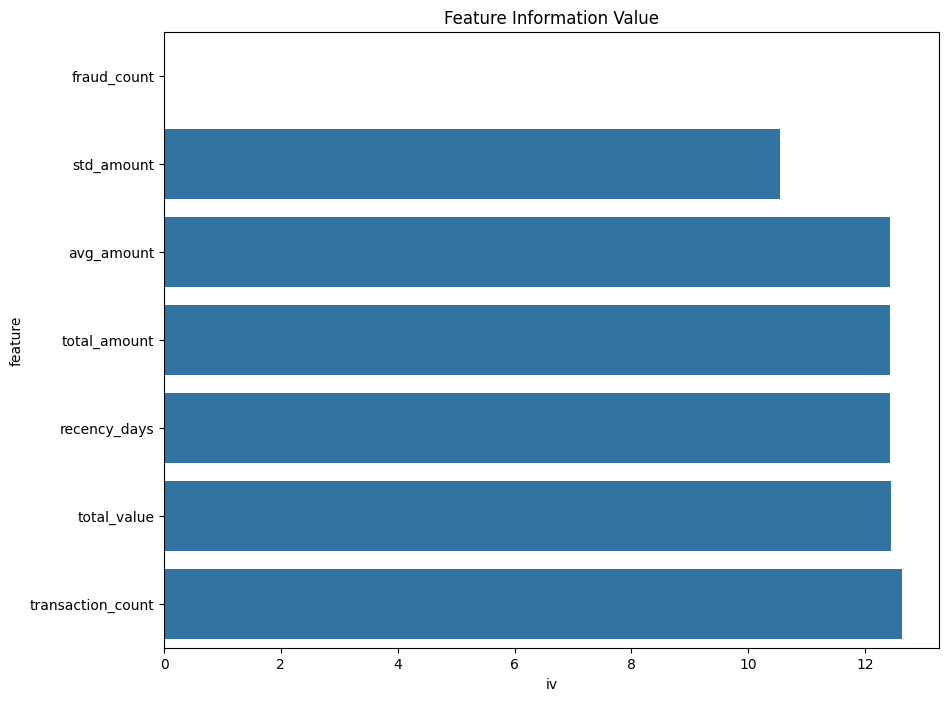

In [19]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=iv_df.sort_values("iv"),
    x="iv",
    y="feature"
)

plt.title("Feature Information Value")
plt.show()

## Weight of Evidence Encoding

For categorical features only.

In [20]:
categorical_cols = [
    "preferred_hour"
]

In [36]:
import importlib
import src.data_processing as dp

importlib.reload(dp)

<module 'src.data_processing' from 'c:\\projects\\week-4-credit-risk-model\\src\\data_processing.py'>

In [30]:
import importlib
import src.data_processing as dp
importlib.reload(dp)

from src.data_processing import compute_all_iv, encode_woe, build_risk_label

# Make sure you have the risk label
customer_features = build_risk_label(customer_features)

# WoE on selected categoricals
categorical_cols = ["preferred_hour", "PricingStrategy"]   # add more if needed

df_woe, woe_maps = encode_woe(customer_features, categorical_cols)

print("WoE encoding successful!")
print(df_woe.columns.tolist())
df_woe.head()

2026-06-03 22:53:45,801 [INFO] Risk label assigned. High-risk cluster: 2 | is_high_risk=1: 1 / 3742


WoE encoding successful!
['CustomerId', 'total_amount', 'avg_amount', 'std_amount', 'max_amount', 'min_amount', 'transaction_count', 'total_value', 'avg_value', 'fraud_count', 'first_txn', 'last_txn', 'recency_days', 'customer_age_days', 'txns_per_day', 'value_per_day', 'preferred_hour', 'weekend_ratio', 'channel_ChannelId_1', 'channel_ChannelId_2', 'channel_ChannelId_3', 'channel_ChannelId_5', 'unique_products', 'unique_categories', 'unique_providers', 'amount_cv', 'avg_ticket_size', 'is_high_risk', 'preferred_hour_woe']


,CustomerId,total_amount,avg_amount,std_amount,max_amount,min_amount,transaction_count,total_value,avg_value,fraud_count,...,channel_ChannelId_2,channel_ChannelId_3,channel_ChannelId_5,unique_products,unique_categories,unique_providers,amount_cv,avg_ticket_size,is_high_risk,preferred_hour_woe
0,CustomerId_1,-10000.0,-10000.000000,NaN,-10000.0,-10000.0,1,10000,10000.000000,0,...,1,0,0,1,1,1,NaN,10000.000000,0,2.754838
1,CustomerId_10,-10000.0,-10000.000000,NaN,-10000.0,-10000.0,1,10000,10000.000000,0,...,1,0,0,1,1,1,NaN,10000.000000,0,2.754838
2,CustomerId_1001,20000.0,4000.000000,6558.963333,10000.0,-5000.0,5,30400,6080.000000,0,...,2,3,0,3,2,3,1.639741,6080.000000,0,-11.085572
3,CustomerId_1002,4225.0,384.090909,560.498966,1500.0,-75.0,11,4775,434.090909,0,...,6,5,0,3,2,2,1.459287,434.090909,0,-10.986566
4,CustomerId_1003,20000.0,3333.333333,6030.478146,10000.0,-5000.0,6,32000,5333.333333,0,...,2,4,0,4,2,3,1.809143,5333.333333,0,-10.986566


In [31]:
# Select features for modeling
woe_cols = [c for c in df_woe.columns if c.endswith("_woe")]
numerical_cols = ["recency_days", "transaction_count", "total_amount", 
                  "avg_amount", "std_amount", "txns_per_day", "weekend_ratio", 
                  "unique_categories", "amount_cv"]

final_features = numerical_cols + woe_cols + ["is_high_risk"]

model_data = df_woe[final_features].copy()
model_data.head()

,recency_days,transaction_count,total_amount,avg_amount,std_amount,txns_per_day,weekend_ratio,unique_categories,amount_cv,preferred_hour_woe,is_high_risk
0,84,1,-10000.0,-10000.000000,NaN,0.011905,0.000000,1,NaN,2.754838,0
1,84,1,-10000.0,-10000.000000,NaN,0.011905,0.000000,1,NaN,2.754838,0
2,90,5,20000.0,4000.000000,6558.963333,0.055556,0.000000,2,1.639741,-11.085572,0
3,26,11,4225.0,384.090909,560.498966,0.122222,0.181818,2,1.459287,-10.986566,0
4,12,6,20000.0,3333.333333,6030.478146,0.500000,0.000000,2,1.809143,-10.986566,0


# Finally ready to train this model

In [ ]:
output_path = Path("..") / "data" / "processed" / "customer_features.csv"
model_data.to_csv(output_path, index=False)
print("Saved model-ready dataset to", output_path)
model_data.head()
